# Proyecto Final – Análisis y Predicción de Series Temporales
## Serie: Ventas al por menor en EE.UU. (RSXFSN)
**Máster en Big Data y Business Analytics**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm

from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# 1. Introducción

La serie analizada corresponde a las **ventas minoristas mensuales en Estados Unidos** (código RSXFSN, fuente: FRED / U.S. Census Bureau).  
Recoge el volumen de ventas al por menor en millones de dólares, de forma mensual, desde enero de 2012 hasta diciembre de 2025, lo que supone **168 observaciones**.

El objetivo del estudio es:
- Identificar la tendencia y el patrón estacional de la serie.
- Ajustar un modelo de **suavizado exponencial (Holt-Winters)** y un modelo **SARIMA**.
- Comparar ambos métodos para predecir los últimos 12 meses de la serie (año 2025).

In [2]:
df = pd.read_csv('retail_sales.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'])
df.index = df['observation_date']
df.index.freq = 'MS'
del df['observation_date']

serie = df['RSXFSN']

print(f'Observaciones: {len(serie)}')
print(f'Periodo: {serie.index[0].date()} → {serie.index[-1].date()}')
df.head()

Observaciones: 168
Periodo: 2012-01-01 → 2025-12-01


,RSXFSN
observation_date,
2012-01-01,309548
2012-02-01,324839
2012-03-01,361240
2012-04-01,342428
2012-05-01,365885


# 2. Representación gráfica y descomposición

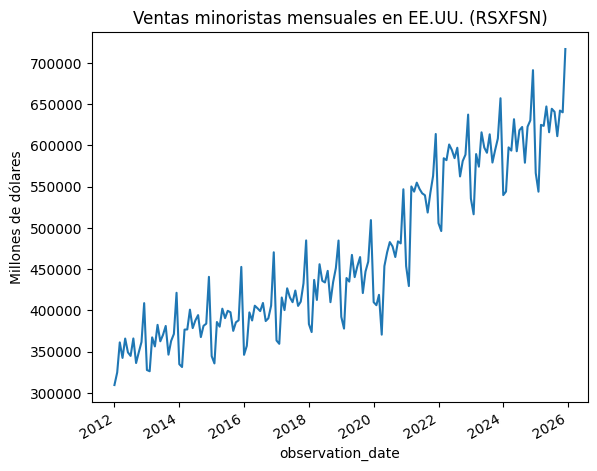

In [3]:
sns.lineplot(serie)
plt.xticks(rotation=30, ha='right')
plt.title('Ventas minoristas mensuales en EE.UU. (RSXFSN)')
plt.ylabel('Millones de dólares')
plt.show()

La serie muestra:
- **Tendencia creciente** a lo largo del período, con una caída puntual en 2020 (COVID-19) seguida de una fuerte recuperación.
- **Estacionalidad anual** clara (pico en diciembre, valle en enero/febrero).
- La varianza crece con el nivel, lo que sugiere **heterocedasticidad** y un modelo multiplicativo.

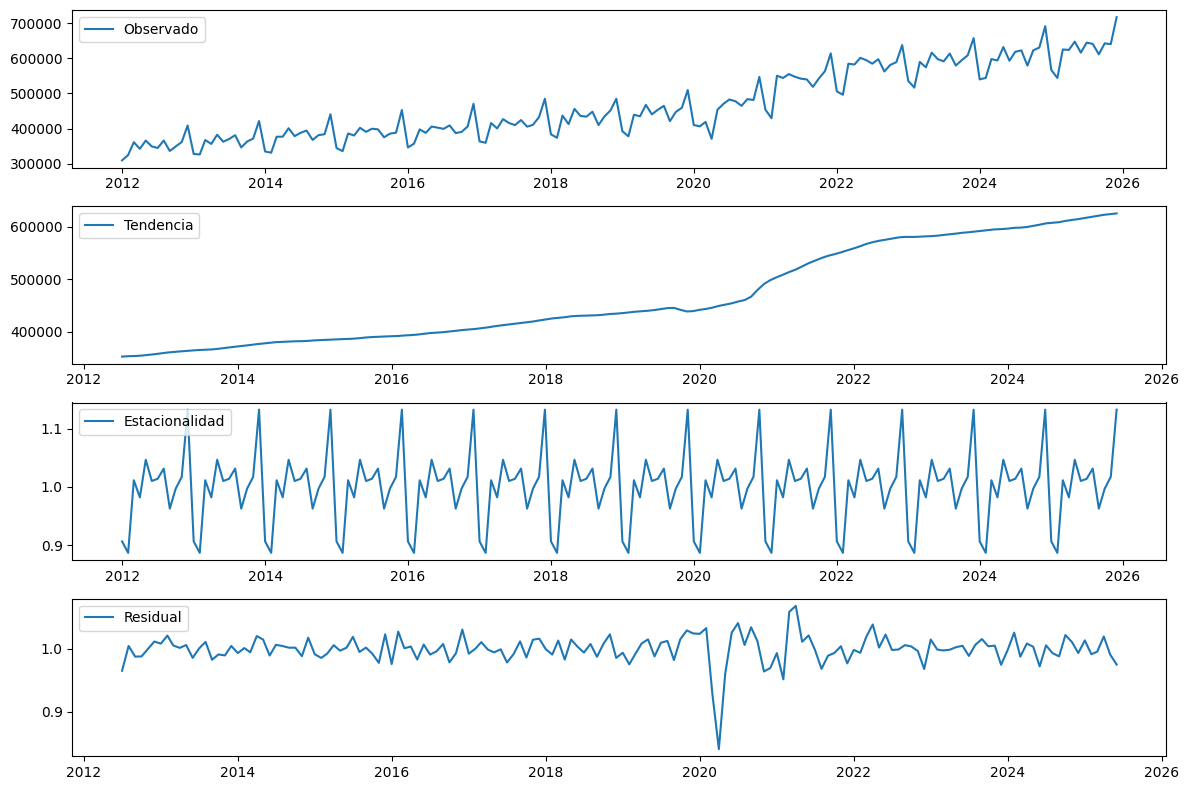

In [4]:
# Descomposición multiplicativa
result = seasonal_decompose(serie, model='multiplicative', period=12)

plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(result.observed, label='Observado')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(result.trend, label='Tendencia')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(result.seasonal, label='Estacionalidad')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(result.resid, label='Residual')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

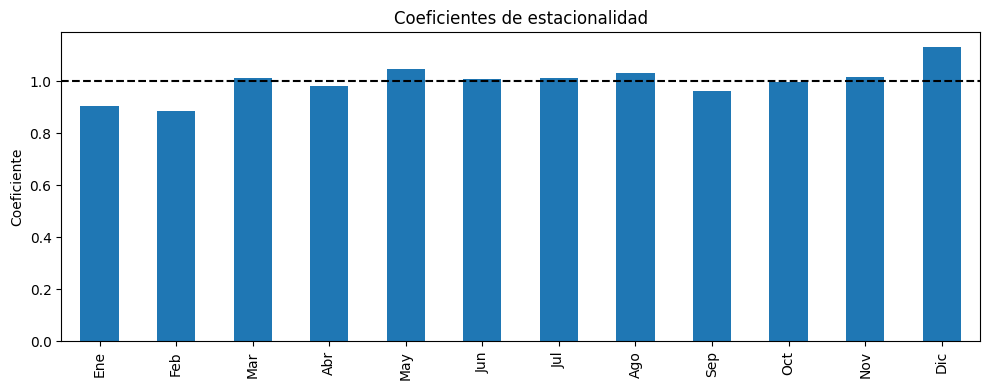

Ene    0.906775
Feb    0.887147
Mar    1.011545
Abr    0.982205
May    1.046640
Jun    1.010216
Jul    1.014070
Ago    1.031518
Sep    0.962914
Oct    0.997150
Nov    1.017378
Dic    1.132443
Name: seasonal, dtype: float64


In [5]:
# Coeficientes estacionales por mes
estacional = result.seasonal
coef_est = estacional.groupby(estacional.index.month).mean()
coef_est.index = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

plt.figure(figsize=(10, 4))
coef_est.plot(kind='bar')
plt.axhline(1, linestyle='--', color='black')
plt.title('Coeficientes de estacionalidad')
plt.ylabel('Coeficiente')
plt.tight_layout()
plt.show()

print(coef_est)

El mes con mayor coeficiente es **diciembre** (ventas notablemente superiores a la media anual), mientras que **enero y febrero** presentan los coeficientes más bajos. El patrón estacional es muy regular a lo largo de todos los años.

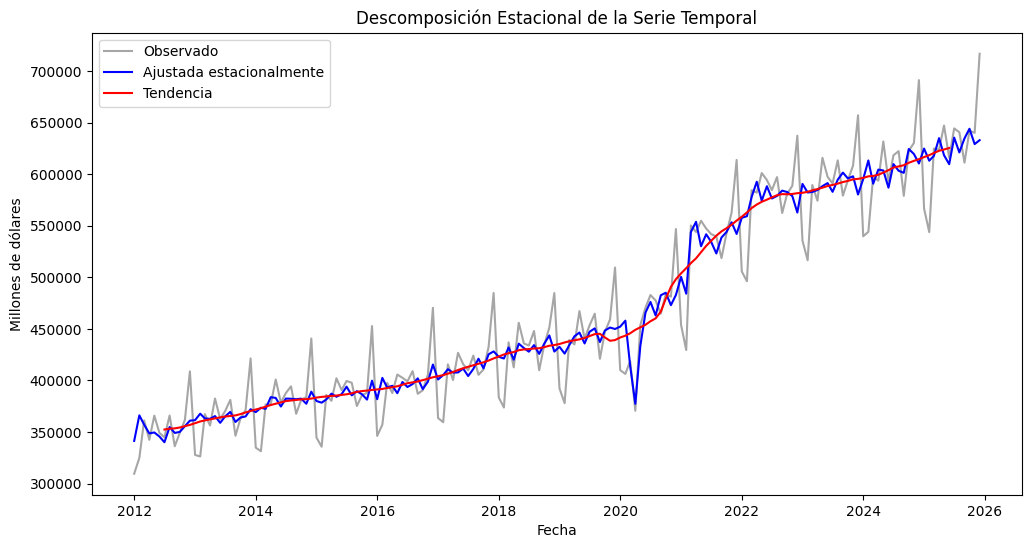

In [6]:
# Serie observada, ajustada estacionalmente y tendencia
plt.figure(figsize=(12, 6))
plt.plot(result.observed, label='Observado', color='grey', alpha=0.7)
plt.plot(result.observed / result.seasonal, label='Ajustada estacionalmente', color='blue')
plt.plot(result.trend, label='Tendencia', color='red')
plt.legend()
plt.title('Descomposición Estacional de la Serie Temporal')
plt.xlabel('Fecha')
plt.ylabel('Millones de dólares')
plt.show()

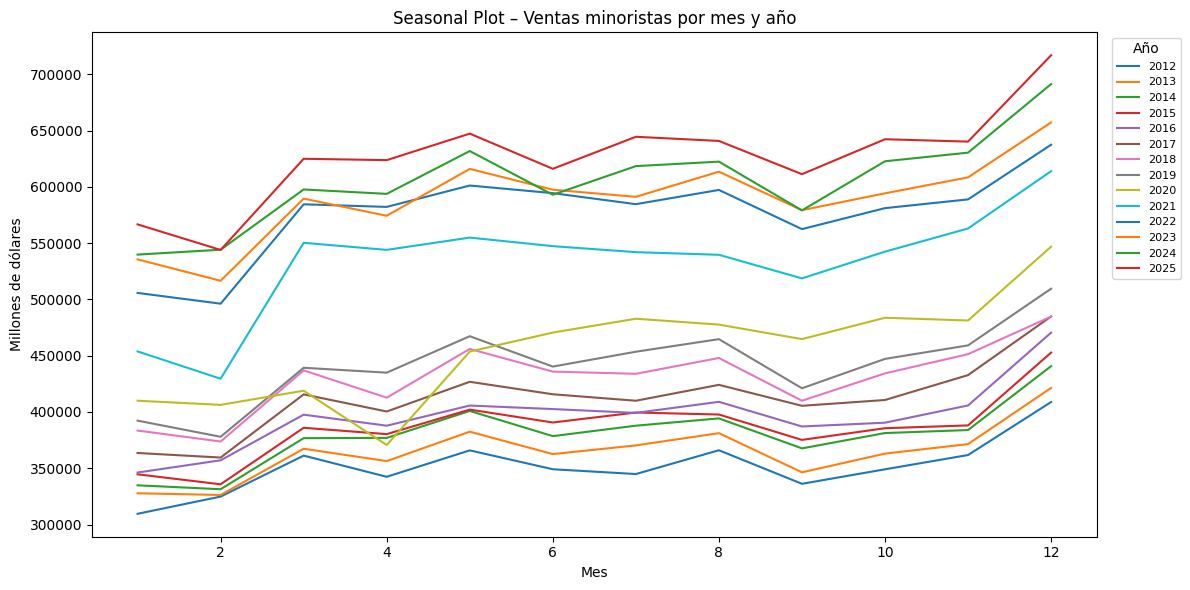

In [7]:
# Seasonal plot: cada año en un color
df['Año'] = serie.index.year
plt.figure(figsize=(12, 6))
for año, datos_año in df.groupby('Año'):
    plt.plot(datos_año.index.month, datos_año['RSXFSN'], label=str(año))
plt.legend(title='Año', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.title('Seasonal Plot – Ventas minoristas por mes y año')
plt.xlabel('Mes')
plt.ylabel('Millones de dólares')
plt.tight_layout()
plt.show()

# 3. Split train / test

Train: 156 obs  (2012-01-01 → 2024-12-01)
Test:  12  obs  (2025-01-01  → 2025-12-01)


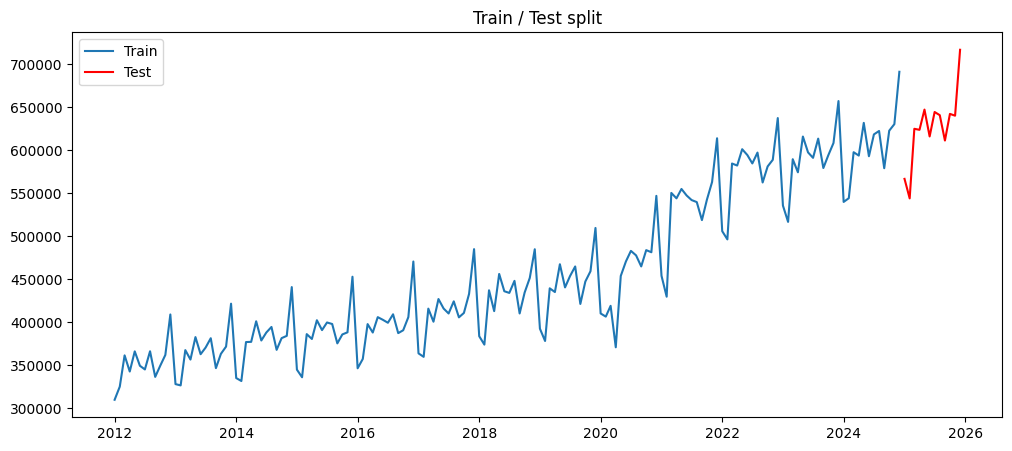

In [8]:
# Reservamos el último año (12 observaciones) como test
train = serie.iloc[:-12]
test  = serie.iloc[-12:]

print(f'Train: {len(train)} obs  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test:  {len(test)}  obs  ({test.index[0].date()}  → {test.index[-1].date()})')

plt.figure(figsize=(12, 5))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='red')
plt.legend()
plt.title('Train / Test split')
plt.show()

# 4. Suavizado exponencial – Holt-Winters

In [9]:
# Comparamos las tres variantes habituales
modelos_hw = {
    'add-add': ('add', 'add'),
    'add-mul': ('add', 'mul'),
    'mul-mul': ('mul', 'mul'),
}

resultados_hw = {}
for nombre, (t, s) in modelos_hw.items():
    m = sm.tsa.ExponentialSmoothing(
        train, trend=t, seasonal=s, seasonal_periods=12
    ).fit()
    pred = m.forecast(12)
    rmse = np.sqrt(mean_squared_error(test, pred))
    mae  = mean_absolute_error(test, pred)
    resultados_hw[nombre] = {'AIC': m.aic, 'RMSE': rmse, 'MAE': mae, 'modelo': m, 'pred': pred}

pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk not in ('modelo','pred')}
              for k, v in resultados_hw.items()}).T

,AIC,RMSE,MAE
add-add,2982.916594,20164.145410,17650.413294
add-mul,2966.792769,9000.440044,7749.228338
mul-mul,2965.399130,11319.548536,9381.417700


Seleccionamos el modelo con menor AIC y menor RMSE sobre el test.

In [10]:
# Selección del mejor modelo
mejor_nombre = min(resultados_hw, key=lambda k: resultados_hw[k]['AIC'])
mejor_hw     = resultados_hw[mejor_nombre]['modelo']
pred_hw      = resultados_hw[mejor_nombre]['pred']

print(f'Mejor modelo: {mejor_nombre}')
mejor_hw.summary()

Mejor modelo: mul-mul


Dep. Variable:,RSXFSN,No. Observations:,156
Model:,ExponentialSmoothing,SSE,22883834576.462
Optimized:,True,AIC,2965.399
Trend:,Multiplicative,BIC,3014.197
Seasonal:,Multiplicative,AICC,2970.392
Seasonal Periods:,12,Date:,"Sun, 07 Jun 2026"
Box-Cox:,False,Time:,19:23:05
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.5074162,alpha,True
smoothing_trend,0.000000,beta,True


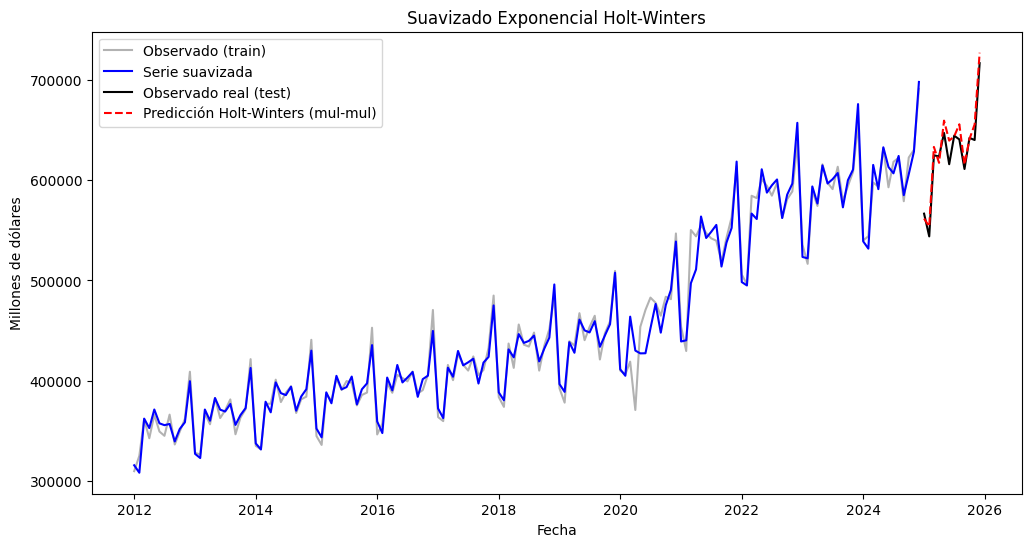

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(train, label='Observado (train)', color='grey', alpha=0.6)
plt.plot(mejor_hw.fittedvalues, label='Serie suavizada', color='blue')
plt.plot(test, label='Observado real (test)', color='black')
plt.plot(pred_hw, label=f'Predicción Holt-Winters ({mejor_nombre})', color='red', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Millones de dólares')
plt.title('Suavizado Exponencial Holt-Winters')
plt.legend()
plt.show()

### Expresión del modelo Holt-Winters

El modelo seleccionado es **Holt-Winters completamente multiplicativo** (tendencia multiplicativa + estacionalidad multiplicativa), cuya ecuación de predicción es:

$$\hat{y}_{t+h} = (L_t \cdot T_t^h) \cdot S_{t+h-m}$$

donde las ecuaciones de actualización son:

$$L_t = \alpha \frac{y_t}{S_{t-m}} + (1-\alpha)(L_{t-1} \cdot T_{t-1})$$
$$T_t = \beta \frac{L_t}{L_{t-1}} + (1-\beta) T_{t-1}$$
$$S_t = \gamma \frac{y_t}{L_t} + (1-\gamma) S_{t-m}$$

con $m=12$ (periodo estacional mensual) y parámetros óptimos estimados:

| Parámetro | Valor | Interpretación |
|---|---|---|
| $\hat{\alpha} = 0.507$ | nivel | Actualización moderada del nivel |
| $\hat{\beta} = 0.000$ | tendencia | Tendencia muy estable, sin actualización |
| $\hat{\gamma} = 0.000$ | estacionalidad | Patrón estacional fijo a lo largo del tiempo |

# 5. Identificación del modelo SARIMA

### 5.1 Análisis de la serie original y estacionariedad

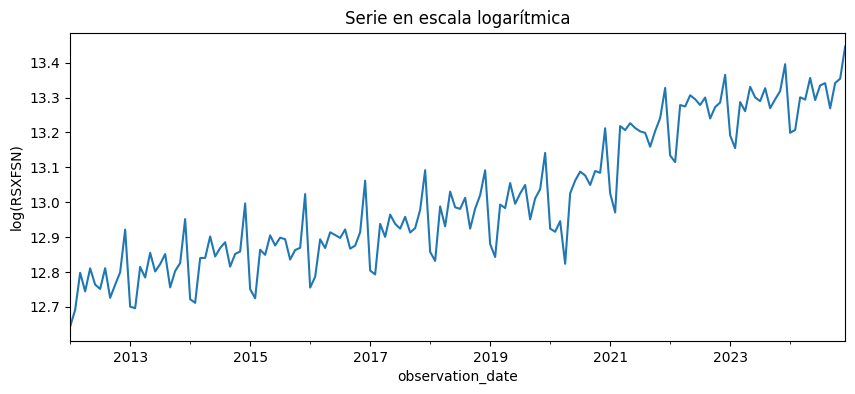

In [12]:
# Aplicamos logaritmo para estabilizar la varianza (serie heterocedástica)
train_log = np.log(train)

train_log.plot(figsize=(10, 4))
plt.title('Serie en escala logarítmica')
plt.ylabel('log(RSXFSN)')
plt.show()

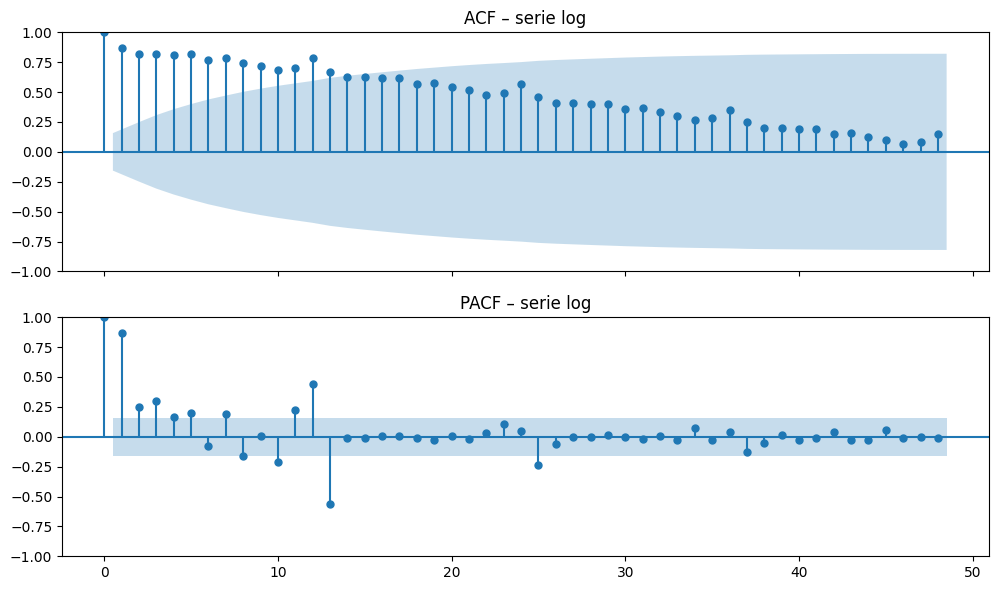

In [13]:
# ACF y PACF de la serie log (sin diferenciar)
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
plot_acf(train_log, ax=axs[0], lags=48, alpha=0.05)
axs[0].set_title('ACF – serie log')
plot_pacf(train_log, ax=axs[1], lags=48, alpha=0.05)
axs[1].set_title('PACF – serie log')
plt.tight_layout()
plt.show()

### 5.2 Diferenciación regular (d=1) y test de raíz unitaria

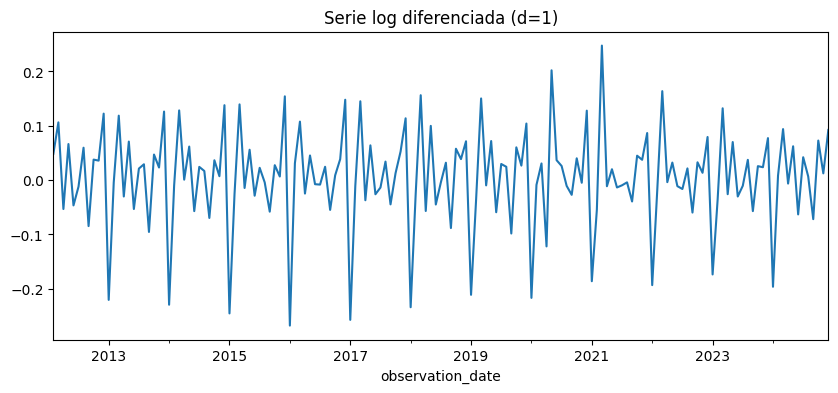

ADF Statistic: -3.1531
p-value:       0.0229
KPSS Statistic: 0.2587
p-value:        0.1000


In [14]:
# Diferenciación de orden 1
train_d1 = train_log.diff().dropna()

train_d1.plot(figsize=(10, 4))
plt.title('Serie log diferenciada (d=1)')
plt.show()

# Test ADF
adf = adfuller(train_d1)
print(f'ADF Statistic: {adf[0]:.4f}')
print(f'p-value:       {adf[1]:.4f}')

# Test KPSS
kpss_res = kpss(train_d1, regression='c')
print(f'KPSS Statistic: {kpss_res[0]:.4f}')
print(f'p-value:        {kpss_res[1]:.4f}')

El test ADF rechaza H₀ (raíz unitaria) → **la serie diferenciada es estacionaria** → d = 1.  
El test KPSS no rechaza H₀ (estacionariedad) → confirma el resultado.  
Por tanto, **d = 1**.

### 5.3 Diferenciación estacional (D=1) y ACF/PACF

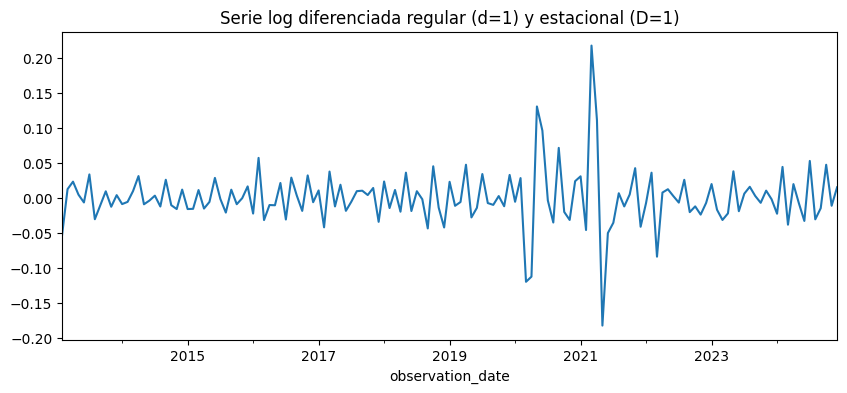

ADF Statistic: -4.1415  |  p-value: 0.0008


In [15]:
# Diferenciación estacional de orden 12
train_d1_D1 = train_d1.diff(12).dropna()

train_d1_D1.plot(figsize=(10, 4))
plt.title('Serie log diferenciada regular (d=1) y estacional (D=1)')
plt.show()

adf2 = adfuller(train_d1_D1)
print(f'ADF Statistic: {adf2[0]:.4f}  |  p-value: {adf2[1]:.4f}')

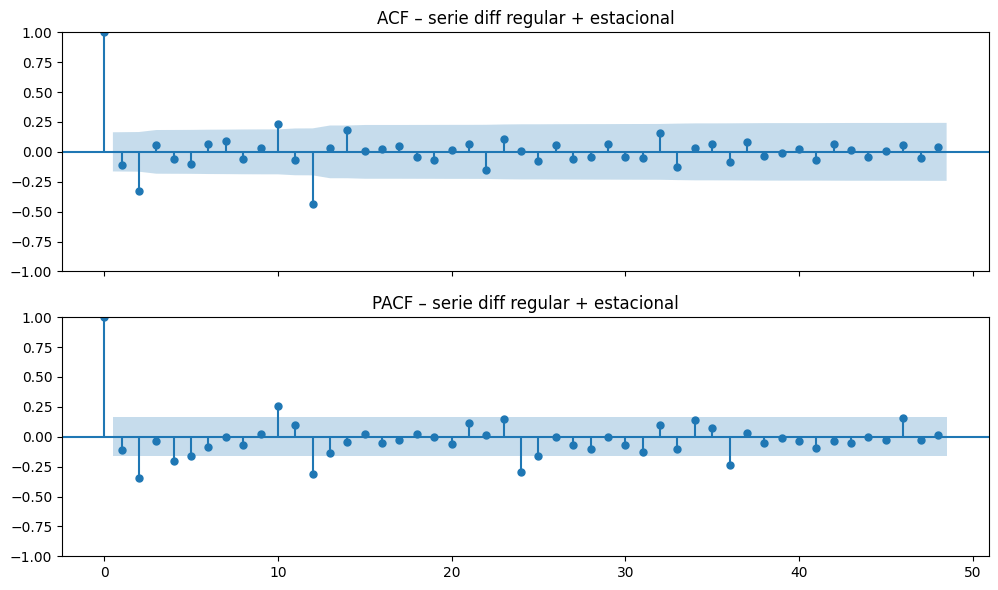

In [16]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
plot_acf(train_d1_D1, ax=axs[0], lags=48, alpha=0.05)
axs[0].set_title('ACF – serie diff regular + estacional')
plot_pacf(train_d1_D1, ax=axs[1], lags=48, alpha=0.05)
axs[1].set_title('PACF – serie diff regular + estacional')
plt.tight_layout()
plt.show()

A partir de los correlogramas:
- **ACF**: corte significativo en el lag 1 → **q = 1**; corte en lag 12 → **Q = 1**.
- **PACF**: decaimiento progresivo → confirma componente MA.

Modelo candidato: **SARIMA(0,1,1)(0,1,1)[12]**. Confirmamos con `auto_arima`.

In [17]:
auto_model = auto_arima(
    train_log,
    d=1, D=1,
    m=12,
    seasonal=True,
    stepwise=True,
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=0.76 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-509.871, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-540.491, Time=0.14 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.35 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-509.756, Time=0.04 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-550.130, Time=0.30 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=-569.337, Time=0.69 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.46 sec
 ARIMA(1,1,0)(2,1,2)[12]             : AIC=inf, Time=1.01 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=inf, Time=0.41 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=0.39 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=-580.495, Time=1.07 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=0.80 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-561.895, Time=0.50 sec
 ARIMA(2,1,0)(2,1,2)[12]             : AIC=inf, Time=1

# 5.4 Ajuste del modelo SARIMA y comprobación de idoneidad

In [18]:
# Ajustamos el modelo seleccionado por auto_arima con SARIMAX
order         = auto_model.order           # (p, d, q)
seasonal_order = auto_model.seasonal_order  # (P, D, Q, m)

print(f'Orden:          {order}')
print(f'Orden estacional: {seasonal_order}')

modelo_sarima = SARIMAX(
    train_log,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

modelo_sarima.summary()

Orden:          (0, 1, 2)
Orden estacional: (2, 1, 1, 12)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                               RSXFSN   No. Observations:                  156
Model:             SARIMAX(0, 1, 2)x(2, 1, [1], 12)   Log Likelihood                 241.917
Date:                              Sun, 07 Jun 2026   AIC                           -471.835
Time:                                      19:23:40   BIC                           -455.160
Sample:                                  01-01-2012   HQIC                          -465.063
                                       - 12-01-2024                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3428      0.052     -6.559      0.000      -0.445      -0.240
ma.L2         -0.2396      0.063     -3.828      0.000      -0.362      -0.117
ar.S.L12      -0.1366      0.148     -0.923      0.356      -0.427       0.153
ar.S.L24      -0.1843      0.152     -1.210      0.226      -0.483       0.114
ma.S.L12      -0.7239      0.152     -4.749      0.000      -1.023      -0.425
sigma2         0.0009   8.64e-05     10.744      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):               116.57
Prob(Q):                              0.76   Prob(JB):                         0.00
Heteroskedasticity (H):               1.47   Skew:                            -0.14
Prob(H) (two-sided):                  0.23   Kurtosis:                         7.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

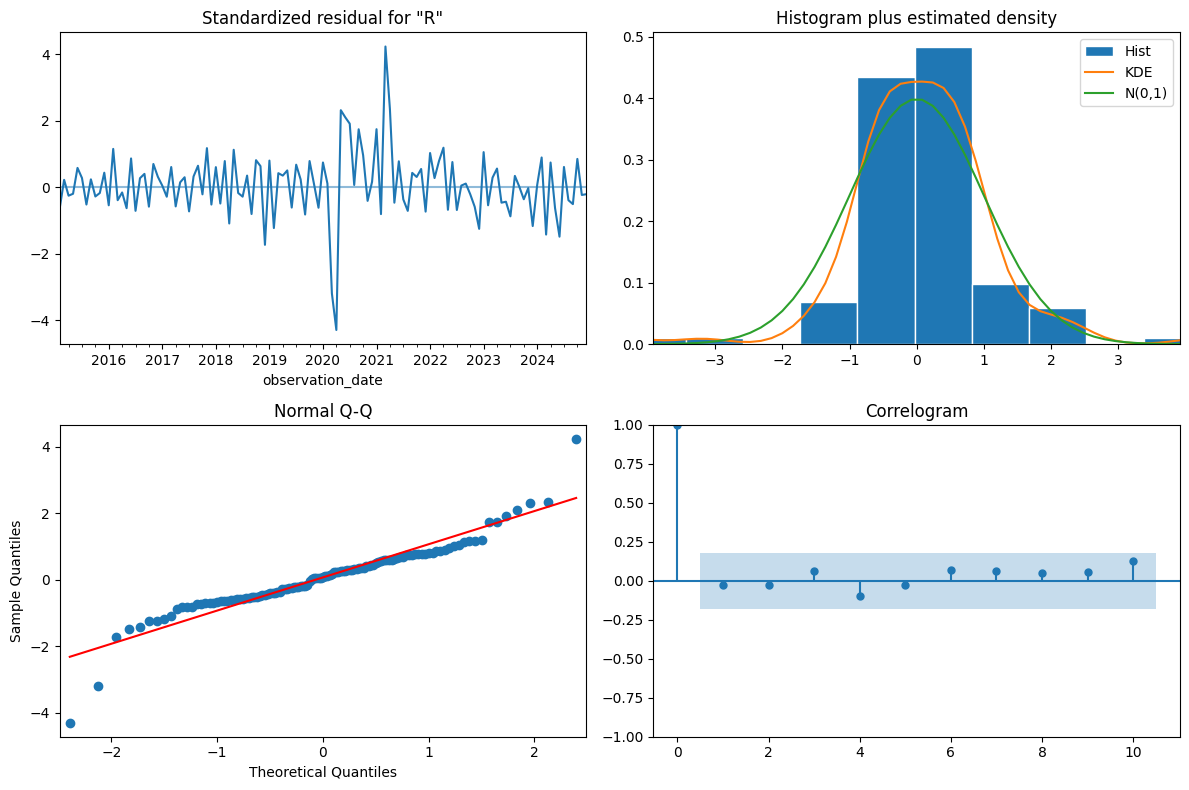

In [19]:
# Diagnóstico de residuos
modelo_sarima.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

Los residuos del modelo deben comportarse como **ruido blanco**: distribución aproximadamente normal, sin autocorrelación significativa en ACF ni en el test de Ljung-Box.

# 6. Predicciones e intervalos de confianza

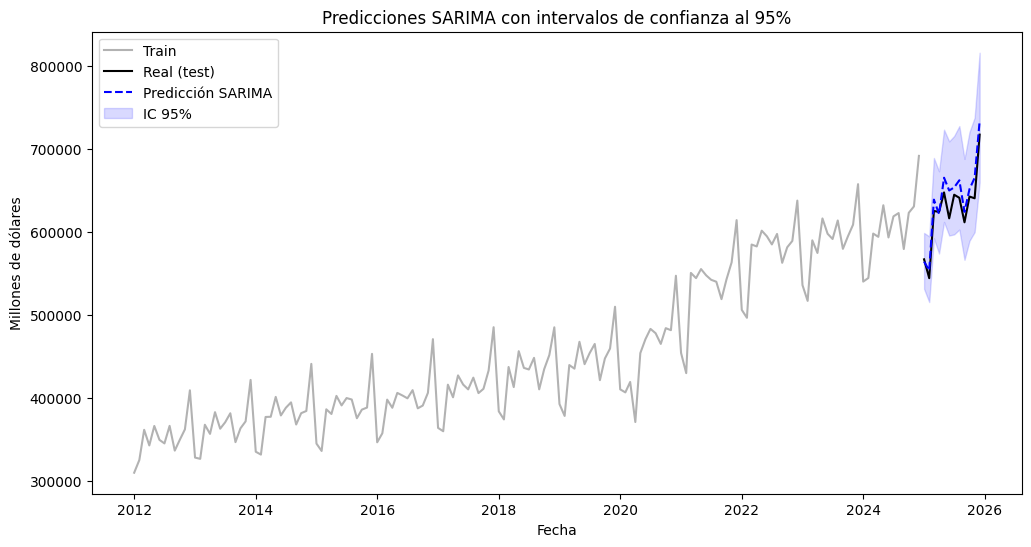

In [20]:
# Predicción sobre el periodo test (12 meses) en escala log
pred_log = modelo_sarima.get_forecast(steps=12)
pred_log_mean = pred_log.predicted_mean
ci_log = pred_log.conf_int(alpha=0.05)

# Volvemos a escala original
pred_sarima   = np.exp(pred_log_mean)
ci_lower      = np.exp(ci_log.iloc[:, 0])
ci_upper      = np.exp(ci_log.iloc[:, 1])

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train', color='grey', alpha=0.6)
plt.plot(test,  label='Real (test)', color='black')
plt.plot(pred_sarima, label='Predicción SARIMA', color='blue', linestyle='--')
plt.fill_between(pred_sarima.index, ci_lower, ci_upper,
                 color='blue', alpha=0.15, label='IC 95%')
plt.xlabel('Fecha')
plt.ylabel('Millones de dólares')
plt.title('Predicciones SARIMA con intervalos de confianza al 95%')
plt.legend()
plt.show()

In [21]:
# Tabla de predicciones vs valores reales
tabla_sarima = pd.DataFrame({
    'Real':         test.values,
    'Pred SARIMA':  pred_sarima.values,
    'IC inf (95%)': ci_lower.values,
    'IC sup (95%)': ci_upper.values
}, index=test.index)

tabla_sarima

,Real,Pred SARIMA,IC inf (95%),IC sup (95%)
observation_date,,,,
2025-01-01,566662,563783.845052,531089.720685,598490.634561
2025-02-01,543970,553314.944690,515142.367108,594316.149409
2025-03-01,624954,638610.567815,592045.889097,688837.579715
2025-04-01,623756,621233.460501,573635.077463,672781.403384
2025-05-01,647306,664996.441872,611709.169259,722925.680905
2025-06-01,616031,649596.819396,595369.614134,708763.124203
2025-07-01,644493,653331.056689,596700.999866,715335.603141
2025-08-01,640803,661919.832800,602512.449770,727184.749827
2025-09-01,611277,623879.454708,566042.577658,687625.965555


# 7. Comparación de métodos y conclusiones

In [22]:
rmse_hw     = np.sqrt(mean_squared_error(test, pred_hw))
mae_hw      = mean_absolute_error(test, pred_hw)
rmse_sarima = np.sqrt(mean_squared_error(test, pred_sarima))
mae_sarima  = mean_absolute_error(test, pred_sarima)

comparacion = pd.DataFrame({
    f'Holt-Winters ({mejor_nombre})': {'RMSE': rmse_hw, 'MAE': mae_hw},
    'SARIMA':                         {'RMSE': rmse_sarima, 'MAE': mae_sarima}
}).T

print(comparacion.to_string())

                                RMSE           MAE
Holt-Winters (mul-mul)  11319.548536   9381.417700
SARIMA                  16744.806647  14341.234237


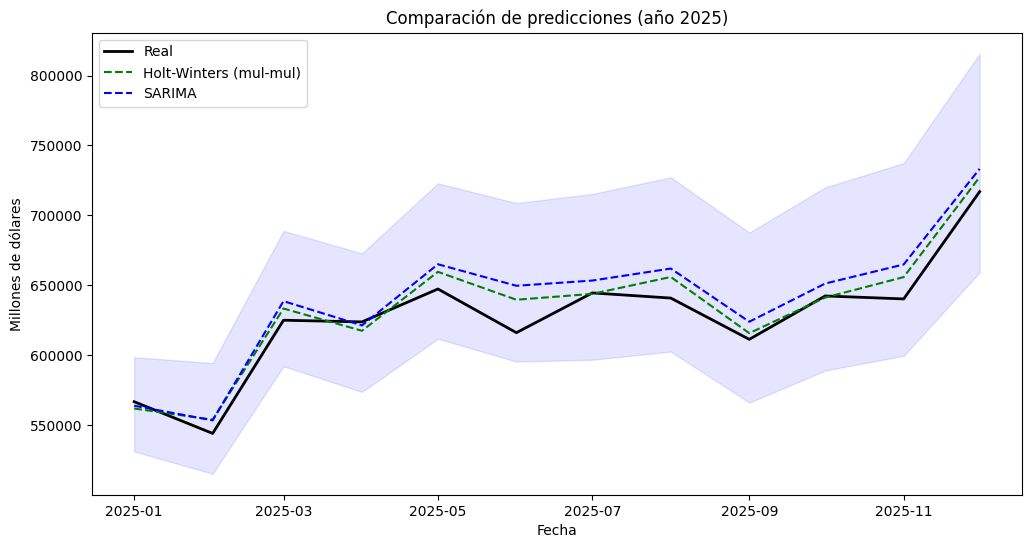

In [ ]:
# Gráfico comparativo
plt.figure(figsize=(12, 6))
plt.plot(test, label='Real', color='black', linewidth=2)
plt.plot(pred_hw,     label=f'Holt-Winters ({mejor_nombre})', color='green',  linestyle='--')
plt.plot(pred_sarima, label='SARIMA',                          color='blue',   linestyle='--')
plt.fill_between(pred_sarima.index, ci_lower, ci_upper,
                 color='blue', alpha=0.1)
plt.xlabel('Fecha')
plt.ylabel('Millones de dólares')
plt.title('Comparación de predicciones (año 2025)')
plt.legend()
plt.show()